In [15]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

In [16]:

df = pd.read_csv("flower_dataset.csv")


print("First 5 rows of the dataset:")
print(df.head())

print("\nColumns in the dataset:")
print(df.columns)

First 5 rows of the dataset:
           species    size fragrance  height_cm
0             rose  medium      mild      48.55
1  shoeblack plant  medium      mild     147.07
2  shoeblack plant  medium      none     102.93
3         hibiscus   large      none     184.00
4  shoeblack plant   large      mild      83.07

Columns in the dataset:
Index(['species', 'size', 'fragrance', 'height_cm'], dtype='object')


In [17]:

data = df.copy()


size_encoder = LabelEncoder()
fragrance_encoder = LabelEncoder()

data["size_encoded"] = size_encoder.fit_transform(data["size"])
data["fragrance_encoded"] = fragrance_encoder.fit_transform(data["fragrance"])

print("\nUnique values mapping for 'size':")
for label, code in zip(size_encoder.classes_, range(len(size_encoder.classes_))):
    print(f"{label} -> {code}")

print("\nUnique values mapping for 'fragrance':")
for label, code in zip(fragrance_encoder.classes_, range(len(fragrance_encoder.classes_))):
    print(f"{label} -> {code}")


Unique values mapping for 'size':
large -> 0
medium -> 1
small -> 2

Unique values mapping for 'fragrance':
mild -> 0
none -> 1
strong -> 2


In [18]:

X = data[["size_encoded", "fragrance_encoded", "height_cm"]]

print("\nFeature matrix (first 5 rows):")
print(X.head())


Feature matrix (first 5 rows):
   size_encoded  fragrance_encoded  height_cm
0             1                  0      48.55
1             1                  0     147.07
2             1                  1     102.93
3             0                  1     184.00
4             0                  0      83.07


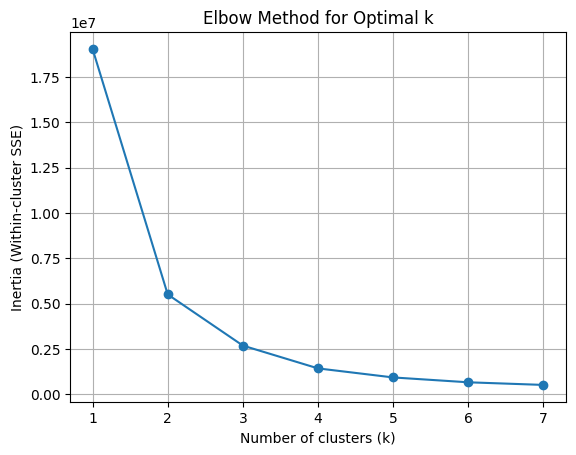

In [19]:
import matplotlib.pyplot as plt

inertias = []
k_values = range(1, 8)  # try k = 1 to 7

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

In [20]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)

kmeans.fit(X)

cluster_labels = kmeans.labels_


data["cluster"] = cluster_labels

print("\nCluster centers (in terms of features):")
print(kmeans.cluster_centers_)

print("\nFirst 10 rows with assigned clusters:")
print(data[["species", "size", "fragrance", "height_cm", "cluster"]].head(10))


Cluster centers (in terms of features):
[[1.19984140e+00 8.44832144e-01 6.04708142e+01]
 [9.26222935e-02 9.17000802e-01 1.64285369e+02]
 [5.21890948e-01 7.68197690e-01 1.10193548e+02]]

First 10 rows with assigned clusters:
           species    size fragrance  height_cm  cluster
0             rose  medium      mild      48.55        0
1  shoeblack plant  medium      mild     147.07        1
2  shoeblack plant  medium      none     102.93        2
3         hibiscus   large      none     184.00        1
4  shoeblack plant   large      mild      83.07        0
5         hibiscus   large      none     120.88        2
6             rose   small      mild      99.24        2
7             rose   small    strong      96.75        2
8         hibiscus   large      none     160.88        1
9  shoeblack plant   large      mild      60.43        0


In [21]:

print("\nSpecies vs Cluster (cross-tab):")
print(pd.crosstab(data["species"], data["cluster"]))


Species vs Cluster (cross-tab):
cluster             0     1     2
species                          
hibiscus            0  2040  1278
rose             2634     0   711
shoeblack plant  1156   449  1732


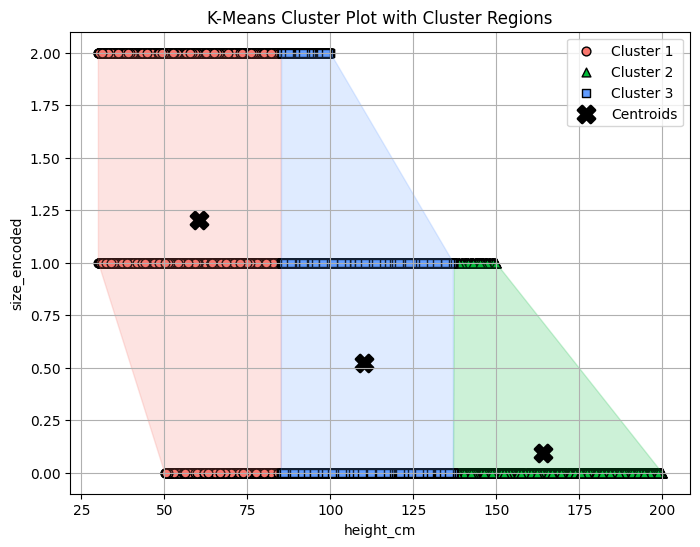

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull

feature_x = "height_cm"
feature_y = "size_encoded"

X_vis = data[[feature_x, feature_y]].values


k = 3
kmeans_vis = KMeans(n_clusters=k, random_state=42)
kmeans_vis.fit(X_vis)

labels = kmeans_vis.labels_
centers = kmeans_vis.cluster_centers_

colors  = ["#F8766D", "#00BA38", "#619CFF"]
markers = ["o", "^", "s"]

plt.figure(figsize=(8, 6))


for c in range(k):
    cluster_points = X_vis[labels == c]


    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        c=colors[c],
        marker=markers[c],
        edgecolor="k",
        s=40,
        label=f"Cluster {c+1}"
    )


    if cluster_points.shape[0] >= 3:
        hull = ConvexHull(cluster_points)
        hull_pts = cluster_points[hull.vertices]
        plt.fill(
            hull_pts[:, 0],
            hull_pts[:, 1],
            color=colors[c],
            alpha=0.2
        )


plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    marker="X",
    s=150,
    linewidths=2,
    label="Centroids"
)

plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title("K-Means Cluster Plot with Cluster Regions")
plt.legend()
plt.grid(True)
plt.show()